Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/var/folders/__/pn5kx9bj2szdqpyrgp8rkfsr0000gn/T/ipykernel_6648/1148360983.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')


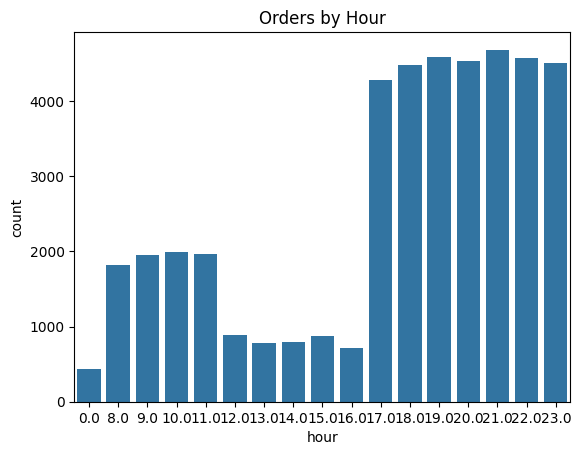

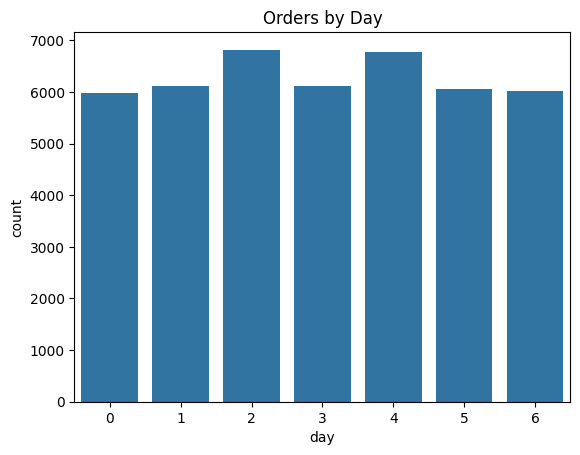

MSE: 69.77992570808293
MAE: 6.692681234941445
R2 Score: 0.2045876721745804
hour       0.871247
day        0.061706
month      0.059796
weekend    0.007252
dtype: float64


In [2]:
%pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('Data/orders.csv')
df = df.dropna()

df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')

df['hour'] = df['Time_Orderd'].dt.hour
df['day'] = df['Order_Date'].dt.dayofweek
df['month'] = df['Order_Date'].dt.month
df['weekend'] = df['day'].apply(lambda x: 1 if x >= 5 else 0)

df['Time_taken(min)'] = df['Time_taken(min)'].str.extract('(\d+)').astype(float)
df = df.dropna()

sns.countplot(x='hour', data=df)
plt.title("Orders by Hour")
plt.show()

sns.countplot(x='day', data=df)
plt.title("Orders by Day")
plt.show()

X = df[['hour', 'day', 'month', 'weekend']]
y = df['Time_taken(min)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("R2 Score:", r2_score(y_test, preds))

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))

df.to_csv('Data/cleaned_data.csv', index=False)
